<a href="https://colab.research.google.com/github/jamespmanning/emolt/blob/main/erddap_combine_CMAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title **Install "erddapy" with each time you log in to COLAB**
!pip install erddapy

In [6]:
#@title **Simply import erddapy and then specify eMOLT, lat/lon, time, and variables you want**
from erddapy import ERDDAP

e = ERDDAP(
  server ="https://cioosatlantic.ca/erddap/",
  protocol="tabledap",
)
e.response = "csv"
e.dataset_id="9qw2-yb2f"
e.constraints = {
    "time>=": "2016-07-10T00:00:00Z",
    "time<=": "2017-02-10T00:00:00Z",
    "latitude>=": 43.0,
    "latitude<=": 45.0,
    "longitude>=": -68.0,
    "longitude<=": -65.0,
}
e.variables = [
    "depth",
    "latitude",
    "longitude",
    "temperature",
    "time",
]

df_yarm = e.to_pandas()


In [7]:
#@title **Now add CFRF observations**
e.dataset_id="wpsu-7fer"
df_digb = e.to_pandas()
from pandas import concat
df=concat([df_yarm,df_digb])

In [9]:
#@title **Print some results**
print(str(len(df_yarm))+' yarmouth obs')
print(str(len(df_digb))+' digby obs')
df

5161 yarmouth obs
2270 digby obs


,depth (m),latitude (degrees_north),longitude (degrees_east),temperature (degrees_Celsius),time (UTC)
0,5.0,43.72102,-65.84574,16.272,2016-07-10T00:00:00Z
1,5.0,43.72102,-65.84574,16.606,2016-07-10T01:00:00Z
2,5.0,43.72102,-65.84574,15.461,2016-07-10T02:00:00Z
3,5.0,43.72102,-65.84574,15.629,2016-07-10T03:00:00Z
4,5.0,43.72102,-65.84574,15.438,2016-07-10T04:00:00Z
...,...,...,...,...,...
2265,1.0,44.40710,-66.16053,12.751,2016-10-12T09:00:00Z
2266,1.0,44.40710,-66.16053,12.751,2016-10-12T10:00:00Z
2267,1.0,44.40710,-66.16053,12.751,2016-10-12T11:00:00Z
2268,1.0,44.40710,-66.16053,12.775,2016-10-12T12:00:00Z


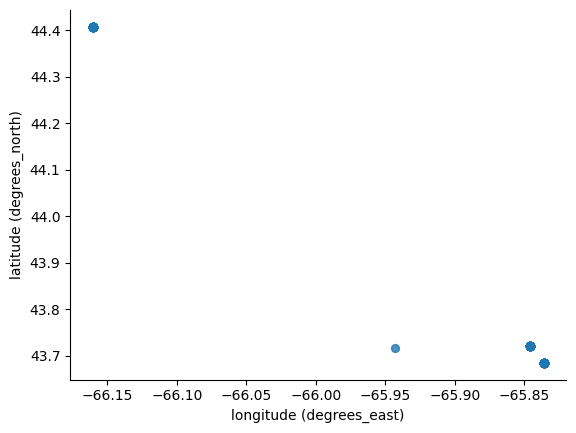

In [11]:
# @title latitude (degrees_north) vs longitude (degrees_east)

from matplotlib import pyplot as plt
df.plot(kind='scatter', y='latitude (degrees_north)', x='longitude (degrees_east)', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)